In [ ]:
# Author: Changho Lee
# Title: Crash Screening Methodology Comparison
# Date: Feb 5, 2025

# Job Instructions and checklist.

"""
 [X @ Cell 1,2] CSV imported, points display correctly

 [X ] Context layers added (roads + boundary at minimum)

 [] Map A: 5-class Quantile on rank_SW

 [] Map B: same ramp + same breaks as Map A

 [] Map C: 7-class diverging centered at 0 on rank_delta_SA_minus_SW

 [] Labels: top 1–5% by abs(delta) only

 [] Map C is the visual anchor

 [] “Analyst’s Perspective” box included

 [] Export one high-res PDF (print-ready)
"""


In [2]:
### Cell 0: Initial Settings
import arcpy
import pandas as pd
import os
import osmnx as ox  #Cell 2
import matplotlib.pyplot as plt

# Parameters
aprx = arcpy.mp.ArcGISProject("CURRENT")
aprxcwd = arcpy.env.workspace
os.chdir(r"D:\PostPhD\250206_Lubbock_ArcGISTest\CrashScreeningMethodologyComparison")
pycwd=os.getcwd()

# Check Messages
print(f"Default GDB: {aprx.defaultGeodatabase}")
print(f"Current Workspace: {aprxcwd}")
print(f"Python CWD: {pycwd}")

Default GDB: D:\PostPhD\250206_Lubbock_ArcGISTest\CrashScreeningMethodologyComparison\CrashScreeningMethodologyComparison.gdb
Current Workspace: D:\PostPhD\250206_Lubbock_ArcGISTest\CrashScreeningMethodologyComparison\CrashScreeningMethodologyComparison.gdb
Python CWD: D:\PostPhD\250206_Lubbock_ArcGISTest\CrashScreeningMethodologyComparison


In [35]:
### Cell 1: Pre-processing CSV file
# Read raw data
raw_data = pd.read_csv("lubbock_intersection_rankings.csv")
#print(raw_data.head())
#print(raw_data.shape)

# Pre-processing key table
key_df=raw_data["intersection_key"].str.split("|",expand=True)
key_df.columns=["County", "City", "Lat", "Long", "RdNm1", "RdNm2"]
#print(key_df.head())
#print(key_df.shape)

# Concate two df into one.
df_proc = pd.concat([key_df,raw_data[["rank_SW","rank_SA","rank_delta_SA_minus_SW"]],raw_data[["Latitude","Longitude","intersection_key"]]],axis=1)
print(df_proc.head())
print(df_proc.shape)

df_proc.to_csv("lubbock_intersection_rankings_clean.csv")

    County                       City      Lat       Long       RdNm1  \
0  LUBBOCK                  ABERNATHY  33.8197  -101.8412      FM0597   
1  LUBBOCK                  ABERNATHY  33.8262  -101.8379               
2  LUBBOCK                  ABERNATHY  33.8264  -101.8431  3RD STREET   
3  LUBBOCK                  ABERNATHY  33.8271  -101.8410      IH0027   
4  LUBBOCK  BUFFALO SPRINGS (LUBBOCK)  33.5241  -101.7275               

          RdNm2  rank_SW  rank_SA  rank_delta_SA_minus_SW  Latitude  \
0        SL0369   1312.0    877.0                  -435.0   33.8197   
1        CR2400   4152.0   3090.0                 -1062.0   33.8262   
2      AVENUE D   4152.0   2769.0                 -1383.0   33.8264   
3  NOT REPORTED   4152.0   5680.0                  1528.0   33.8271   
4        FM0835   4152.0   3510.0                  -642.0   33.5241   

   Longitude                                   intersection_key  
0  -101.8412  LUBBOCK|ABERNATHY|33.8197|-101.8412|FM0597|SL0369  
1 

C:/Users/lestr/AppData/Local/Temp/ArcGISProTemp13520/xpython_13520/1064223034.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(cities.geometry.centroid.x, cities.geometry.centroid.y, cities.name):


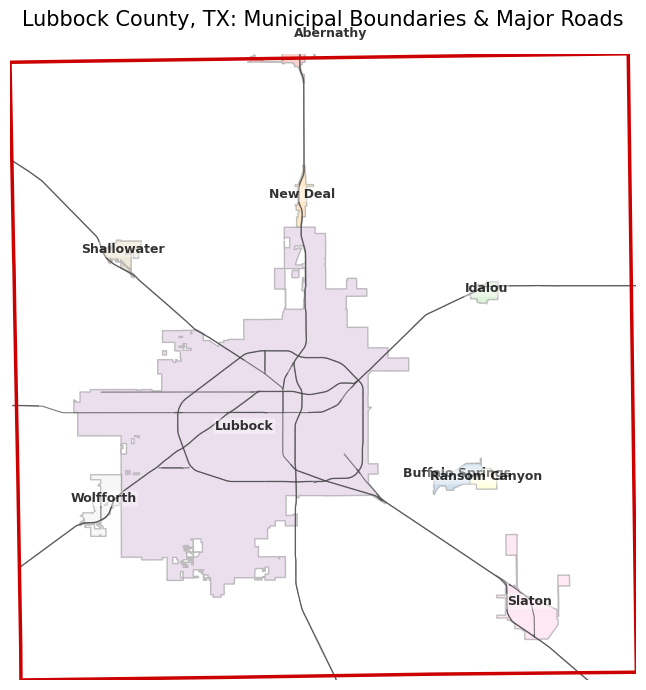

Index(['geometry', 'highway', 'ref', 'NHS', 'Texas_Trunk_System', 'expressway',
       'hgv', 'hgv:national_network', 'lanes', 'noname', 'oneway',
       'source:Texas_Trunk_System', 'source:hgv:national_network', 'HFCS',
       'addr:county', 'maxspeed', 'sidewalk', 'surface', 'tiger:cfcc',
       'zip_left', 'zip_right', 'name', 'old_ref', 'hazmat', 'source:hazmat',
       'tiger:county', 'tiger:name_base', 'tiger:reviewed', 'fut_ref',
       'bridge', 'layer', 'source:hgv', 'tiger:name_base_1', 'tiger:name_type',
       'tiger:name_direction_prefix', 'alt_name', 'wikidata', 'wikipedia',
       'tiger:zip_left', 'tiger:zip_right', 'name_1', 'maxheight',
       'tiger:name_base_2', 'lanes:backward', 'lanes:forward',
       'turn:lanes:backward', 'tiger:name_type_1', 'change:lanes',
       'destination:ref', 'destination:street', 'lanes:both_ways',
       'turn:lanes:both_ways', 'destination:lanes', 'turn:lanes:forward',
       'turn:lanes', 'foot', 'sidewalk:left', 'sidewalk:right', '

C:/Users/lestr/AppData/Local/Temp/ArcGISProTemp13520/xpython_13520/1064223034.py:66: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  roads_export.to_file("MajorRoads_LubbockCounty.shp")


'\n# 1. Export County Boundary\ncounty.to_file(os.path.join(output_folder, "Lubbock_County.shp"))\n\n# 2. Export City Boundary\ncity.to_file(os.path.join(output_folder, "Lubbock_City.shp"))\n\n'

In [8]:
# Cell 2: Collect visualization-support data



# 1. Get the County Boundary
county = ox.geocode_to_gdf("Lubbock County, Texas")

# 2. Get City Boundaries within the county (e.g., Lubbock City)
cities = ox.features_from_place("Lubbock County, Texas", 
                                tags={"boundary": "administrative", "admin_level": "8"})
# Filter the resulting GeoDataFrame to ensure the county polygon isn't included
# (Sometimes 'features_from_place' includes the parent boundary)
cities = cities[cities['admin_level'] == '8']


# 3. Get Road Networks (Major Roads)
# 'drive' gets drivable public streets
roads = ox.features_from_place("Lubbock County, Texas", tags={"highway": ["motorway", "trunk", "primary"]})

# --- 2. Setup Plotting ---
fig, ax = plt.subplots(figsize=(7, 7))

# --- Layer 1: County Envelope/Background ---
# We use 'facecolor' to give the whole county a light base
county.plot(ax=ax, facecolor="none", edgecolor="#CC0000", linewidth=2.5, linestyle="-", zorder=3)

# --- Layer 2: City Boundaries ---
# Each city gets a unique color from a color map (cmap)
cities.plot(ax=ax, column="name", cmap="Pastel1", edgecolor="#999999", alpha=0.6, zorder=1)

# --- Layer 3: Road Network ---
# Roads go on top to show connectivity across boundaries
roads.plot(ax=ax, color="#444444", linewidth=0.8, alpha=0.7, zorder=2)


# --- 3. Labeling the Cities ---
# Place city names at the center of their polygons
for x, y, label in zip(cities.geometry.centroid.x, cities.geometry.centroid.y, cities.name):
    ax.text(x, y, label, fontsize=9, fontweight='bold', ha='center', alpha=0.8,
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.1'))

# --- 4. Final Map Styling ---
ax.set_title("Lubbock County, TX: Municipal Boundaries & Major Roads", fontsize=15, pad=20)
ax.set_axis_off()

# Use the county envelope to set the map extent
minx, miny, maxx, maxy = county.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.tight_layout()
plt.show()


print(roads.columns)


# 3. Export Roads (Special Handling)
# OSM data often contains 'list' types in columns (like 'lanes' or 'oneway') 
# Shapefiles cannot handle lists, so we drop them or convert them to strings.
roads_export = roads.copy()
for col in roads_export.columns:
    if roads_export[col].apply(lambda x: isinstance(x, list)).any():
        roads_export[col] = roads_export[col].astype(str)

#roads_export.to_file("MajorRoads_LubbockCounty.shp")

# 1. Export County Boundary
#county.to_file( "Lubbock_County.shp")


"""
# 2. Export City Boundary
city.to_file(os.path.join(output_folder, "Lubbock_City.shp"))

"""

In [11]:
### Cell 3: Road data construction
arcpy.analysis.Buffer(
    in_features="MajorRoads_LubbockCounty",
    out_feature_class=r"D:\PostPhD\250206_Lubbock_ArcGISTest\CrashScreeningMethodologyComparison\CrashScreeningMethodologyComparison.gdb\MajorRoads_Buf75ft_allDisv_LubbockCO",
    buffer_distance_or_field="75 Feet",
    line_side="FULL",
    line_end_type="ROUND",
    dissolve_option="ALL",
    dissolve_field=None,
    method="PLANAR"
)

arcpy.topographic.PolygonToCenterline(
    in_features="MajorRoads_Buf75ft_allDisv_LubbockCO",
    out_feature_class=r"D:\PostPhD\250206_Lubbock_ArcGISTest\CrashScreeningMethodologyComparison\CrashScreeningMethodologyComparison.gdb\MajorRoads_Buf75ft_centerline_LubbockCO",
    connecting_features=None
)

<Result 'CrashScreeningMethodologyComparison.gdb\\MajorRoads_Centerline_LubbockCO_150ft'>

In [41]:
### Cell 4: Layer management

# Create points layer from "lubbock_intersection_rankings_clean.csv"
#arcpy.management.MakeXYEventLayer("lubbock_intersection_rankings_clean.csv", "Long", "Lat", "Intersections", 4326)
#arcpy.management.CopyFeatures("Intersections", "CrashScreening_pt.shp")

# Replace EventLayer with RealLayer
"""
m = aprx.listMaps()[0]
for lyr in m.listLayers("Intersections"):
    m.removeLayer(lyr)
    print("Layer removed successfully.")

for lyr in m.listLayers("CrashScreening_pt"):
    lyr.name = "Intersections"
    print("Layer renamed.")
"""

Layer removed successfully.
Layer renamed.
